In [1]:
!wget https://storage.yandexcloud.net/ai-2025/russian_literature.zip

--2025-08-24 12:06:01--  https://storage.yandexcloud.net/ai-2025/russian_literature.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20219459 (19M) [application/zip]
Saving to: ‘russian_literature.zip’

russian_literature. 100%[===================>]  19.28M  4.90MB/s    in 3.9s    

2025-08-24 12:06:06 (4.90 MB/s) - ‘russian_literature.zip’ saved [20219459/20219459]



In [2]:
# Разархивируем датасета во временную папку 'dataset'
!unzip -qo "russian_literature" -d ./dataset

error:  cannot create ./dataset/russian_literature/poems/Blok/╨б╤В╨╕╤Е╨╛╤В╨▓╨╛╤А╨╡╨╜╨╕╤П 1897-1903 ╨│╨│, ╨╜╨╡ ╨▓╨╛╤И╨╡╨┤╤И╨╕╨╡ ╨▓ ╨╛╤Б╨╜╨╛╨▓╨╜╨╛╨╡ ╤Б╨╛╨▒╤А╨░╨╜╨╕╨╡.txt
        File name too long
error:  cannot create ./dataset/russian_literature/publicism/Tolstoy/╨Ф╨╛╨║╨╗╨░╨┤, ╨┐╤А╨╕╨│╨╛╤В╨╛╨▓╨╗╨╡╨╜╨╜╤Л╨╕╠Ж ╨┤╨╗╤П ╨║╨╛╨╜╨│╤А╨╡╤Б╤Б╨░ ╨╛ ╨╝╨╕╤А╨╡ ╨▓ ╨б╤В╨╛╨║╨│╨╛╨╗╤М╨╝╨╡.txt
        File name too long
error:  cannot create ./dataset/russian_literature/publicism/Tolstoy/╨Я╨╛╤З╨╡╨╝╤Г ╤Е╤А╨╕╤Б╤В╨╕╨░╨╜╤Б╨║╨╕╨╡ ╨╜╨░╤А╨╛╨┤╤Л ╨▓╨╛╨╛╨▒╤Й╨╡ ╨╕ ╨▓ ╨╛╤Б╨╛╨▒╨╡╨╜╨╜╨╛╤Б╤В╨╕ ╤А╤Г╤Б╤Б╨║╨╕╨╕╠Ж ╨╜╨░╤Е╨╛╨┤╤П╤В╤Б╤П ╤В╨╡╨┐╨╡╤А╤М ╨▓ ╨▒╨╡╨┤╤Б╤В╨▓╨╡╨╜╨╜╨╛╨╝ ╨┐╨╛╨╗╨╛╨╢╨╡╨╜╨╕╨╕.txt
        File name too long
error:  cannot create ./dataset/russian_literature/prose/Gogol/╨Я╨╛╨▓╨╡╤Б╤В╤М ╨╛ ╤В╨╛╨╝, ╨║╨░╨║ ╨┐╨╛╤Б╤Б╨╛╤А╨╕╨╗╤Б╤П ╨Ш╨▓╨░╨╜ ╨Ш╨▓╨░╨╜╨╛╨▓╨╕╤З ╤Б ╨Ш╨▓╨░╨╜╨╛╨╝ ╨Э╨╕╨║╨╕╤Д╨╛╤А╨╛╨▓╨╕╤З╨╡╨╝.txt
        File name too long


In [9]:
!dir ./dataset/russian_literature/prose

Blok	 Chekhov     Gogol  Herzen     Pushkin	Turgenev
Bryusov  Dostoevsky  Gorky  Lermontov  Tolstoy


In [10]:
!dir ./dataset/russian_literature/poems

Blok  Lermontov  Nekrasov  Pushkin


In [56]:
# Загрузка необходимых библиотек
import glob # Вспомогательный модуль для работы с файловой системой
import numpy as np
from keras import utils
from keras.models import Sequential
from keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Для работы с матрицей ошибок


# Выбираем их явно, чтобы список был перед глазами, и отложилось в голове, что имена писателей (точнее их порядковый номер) - это метки
CLASS_LIST=["Dostoevsky", "Tolstoy", "Turgenev", "Chekhov", "Gorky" ]

all_texts = {} # Собираем в словарь весь датасет

for author in CLASS_LIST:
  all_texts[author] = '' # Инициализируем пустой строкой новый ключ словаря
  for path in glob.glob('./dataset/russian_literature/prose/{}/*.txt'.format(author)) +  glob.glob('./dataset/russian_literature/poems/{}/*.txt'.format(author)): # Поиск файлов по шаблону
    with open(f'{path}', 'r', errors='ignore') as f: # игнорируем ошибки (например символы из другой кодировки)
                # Загрузка содержимого файла в строку
                text = f.read()

    all_texts[author]  += ' ' + text.replace('\n', ' ') # Заменяем символ перехода на новую строку пробелом

In [57]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in all_texts.values())
print(f'Датасет состоит из {total} символов')

Датасет состоит из 29117712 символов


In [58]:
print('Общая выборка по писателям:')
for author in CLASS_LIST:
    # удобный метод форматирования 2 знака после запятой f'{ВЫРАЖЕНИЕ:.2f}'
    print(f'{author} - {len(all_texts[author])} символов, доля в общей базе: {len(all_texts[author])/total*100 :.2f}%')

Общая выборка по писателям:
Dostoevsky - 11221679 символов, доля в общей базе: 38.54%
Tolstoy - 9392435 символов, доля в общей базе: 32.26%
Turgenev - 2345243 символов, доля в общей базе: 8.05%
Chekhov - 1834330 символов, доля в общей базе: 6.30%
Gorky - 4324025 символов, доля в общей базе: 14.85%


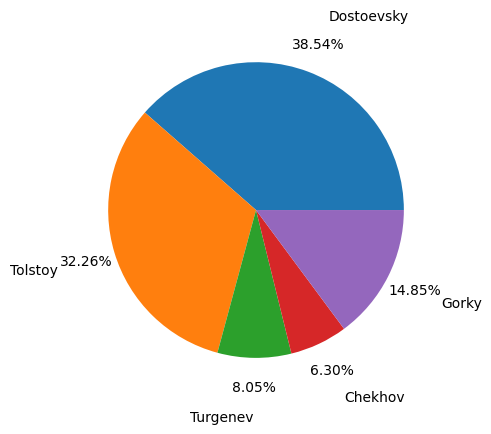

In [59]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots()
ax.pie([len(i) for i in all_texts.values()], # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST,                    # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

### Токенизация

In [17]:
pip install razdel

In [19]:
from razdel import tokenize

In [60]:
NUM_WORDS = 10000  # Размер словаря


# Создаем экземпляр Tokenizer, НО УБИРАЕМ split=' ', так как мы уже разбили текст сами
tokenizer = Tokenizer(
    num_words=NUM_WORDS,
    filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
    lower=True,
    oov_token='неизвестное_слово',
    char_level=False
)

# Вместо простого перебора all_texts.values(), готовим данные с помощью razdel
# Создаем список, где каждый элемент - это список слов одного текста
tokenized_texts = []
for text in all_texts.values():
    # tokenize(text) возвращает генератор объектов Token, из которых берем только текст (.text)
    tokens = [token.text for token in tokenize(text)]
    tokenized_texts.append(tokens)

# Теперь передаем не сырой текст, а уже готовые списки токенов
tokenizer.fit_on_texts(tokenized_texts)

# Всё готово! Словарь построен на основе качественно разобранных слов.
items = list(tokenizer.word_index.items())

In [61]:
# Вывод нескольких наиболее часто встречающихся слов
print("Первые 10 часто встречающих слова", items[:10])

# Размер словаря может быть больше, чем num_words, однако при преобразовании в последовательности или матрицы учитываются только первые num_words слов
print("Размер словаря:", len(items))

Первые 10 часто встречающих слова [('неизвестное_слово', 1), (',', 2), ('.', 3), ('и', 4), ('в', 5), ('не', 6), ('что', 7), ('–', 8), ('я', 9), ('на', 10)]
Размер словаря: 210502


In [63]:
# Проверка индекса слова в словаре
try:
    print('Вы ввели слово с индексом:', tokenizer.word_index[input('Введите слово (в нижнем регистре): ')])
except:
    print('Такого слова нет в словаре')

Введите слово (в нижнем регистре): лошадь
Вы ввели слово с индексом: 570


In [64]:
seq_train = tokenizer.texts_to_sequences(all_texts.values())

In [66]:
author = "Gorky"
cls = CLASS_LIST.index(author)

print("Фрагмент обучающего текста:")
print("В виде оригинального текста:              ", all_texts[author][:120])
print("Он же в виде последовательности индексов: ", seq_train[cls][:20])

Фрагмент обучающего текста:
В виде оригинального текста:                 М. ГОРЬКИЙ НА ДНЕ  КАРТИНЫ. ЧЕТЫРЕ АКТА. Посвящаю Константину Петровичу Пятницкому Действующие лица:Михаил Иванов Кост
Он же в виде последовательности индексов:  [1218, 5385, 10, 4953, 3062, 671, 1, 1, 1, 5996, 1, 1, 318, 2261, 1, 7524, 1, 419, 1, 1]


In [67]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in seq_train)
print(f'Датасет состоит из {total} слов')

Датасет состоит из 4564192 слов


In [68]:
print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    print(f'{author} - {len(seq_train[cls])} слов, доля в общей базе: {len(seq_train[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))

Общая выборка по писателям (по словам):
Dostoevsky - 1779919 слов, доля в общей базе: 39.00%
Tolstoy - 1456418 слов, доля в общей базе: 31.91%
Turgenev - 365152 слов, доля в общей базе: 8.00%
Chekhov - 291031 слов, доля в общей базе: 6.38%
Gorky - 671672 слов, доля в общей базе: 14.72%
Среднее значение слов:  912838.0
Медианное значение слов:  671672.0


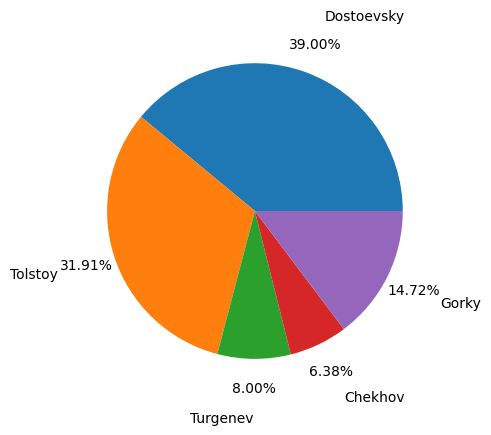

In [69]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train], # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST,                    # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

### Балансировка датасета

In [76]:
median = int(np.median(mean_list)) # Зафиксировали медианное значение
CLASS_LIST_BALANCE = [] # Сбалансированный набор меток
seq_train_balance = []
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    if len(seq_train[cls]) > median * 0.3:
      seq_train_balance.append(seq_train[cls][:median])
      CLASS_LIST_BALANCE.append(author)


In [77]:
total = sum(len(i) for i in seq_train_balance)

print('Сбалансированная выборка по писателям (по словам):')
mean_list_balance = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} слов, доля в общей базе: {len(seq_train_balance[cls])/total*100 :.2f}%')
    mean_list_balance = np.append(mean_list_balance, len(seq_train_balance[cls]))

print('Среднее значение слов: ', np.round(mean_list_balance.mean()))
print('Медианное значение слов: ', np.median(mean_list_balance))

Сбалансированная выборка по писателям (по словам):
Dostoevsky - 671672 слов, доля в общей базе: 25.14%
Tolstoy - 671672 слов, доля в общей базе: 25.14%
Turgenev - 365152 слов, доля в общей базе: 13.67%
Chekhov - 291031 слов, доля в общей базе: 10.90%
Gorky - 671672 слов, доля в общей базе: 25.14%
Среднее значение слов:  534240.0
Медианное значение слов:  671672.0


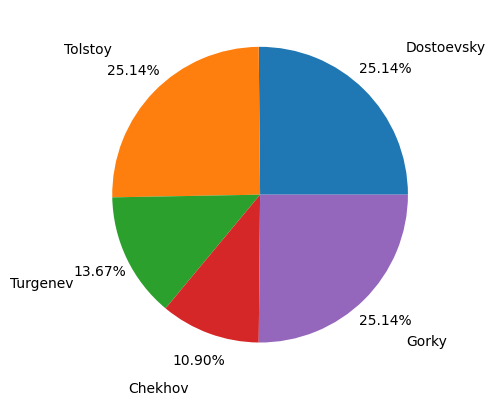

In [78]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance],  # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,            # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

### Создание обучающей и проверочной выборок методом скользящего окна

In [79]:
WIN_SIZE = 1000   # Ширина окна в токенах
WIN_STEP = 100    # Шаг окна в токенах

# Функция разбиения последовательности на отрезки скользящим окном
# Последовательность разбивается на части до последнего полного окна
# Параметры:
# sequence - последовательность токенов
# win_size - размер окна
# step - шаг окна
def seq_split(sequence, win_size, step):
    # Делим строку на отрезки с помощью генератора цикла
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, step)]

def seq_vectorize(
    seq_list,   # Последовательность
    test_split, # Доля на тестовую сборку
    class_list, # Список классов
    win_size,   # Ширина скользящего окна
    step        # Шаг скользящего окна
):

    # Списки для результирующих данных
    x_train, y_train, x_test, y_test =  [], [], [], []

    # Пробежимся по всем классам:
    for class_item in class_list:
        # Получим индекс класса
        cls = class_list.index(class_item)

        # Пороговое значение индекса для разбивки на тестовую и обучающую выборки
        gate_split = int(len(seq_list[cls]) * (1-test_split))

        # Разбиваем последовательность токенов класса на отрезки
        vectors_train = seq_split(seq_list[cls][:gate_split], win_size, step) # последовательность до порога попадет в обучающую выборку
        vectors_test = seq_split(seq_list[cls][gate_split:], win_size, step)  # последовательность после порога попадет в тестовую выборку

        # Добавляем отрезки в выборку
        x_train += vectors_train
        x_test += vectors_test

        # Для всех отрезков класса добавляем метки класса в виде one-hot-encoding
        # Каждую метку берем len(vectors) раз, так она одинакова для всех выборок одного класса
        y_train += [utils.to_categorical(cls, len(class_list))] * len(vectors_train)
        y_test += [utils.to_categorical(cls, len(class_list))] * len(vectors_test)

    # Возвращаем результатов как numpy-массивов
    return np.array(x_train), np.array(y_train), np.array(x_test), np.array(y_test)

x_train, y_train, x_test, y_test = seq_vectorize(seq_train_balance, 0.1, CLASS_LIST_BALANCE, WIN_SIZE, WIN_STEP)


In [80]:
print(f'Форма входных данных для обучающей выборки: {x_train.shape}')
print(f'Форма выходных данных (меток) для обучающей выборки: {y_train.shape}')

Форма входных данных для обучающей выборки: (23995, 1000)
Форма выходных данных (меток) для обучающей выборки: (23995, 5)


In [81]:
print(f'Форма входных данных для тестовой выборки: {x_test.shape}')
print(f'Форма выходных данных (меток) для тестовой выборки: {y_test.shape}')

Форма входных данных для тестовой выборки: (2624, 1000)
Форма выходных данных (меток) для тестовой выборки: (2624, 5)


### Вспомогательные функции

In [82]:
# Вывод графиков точности и ошибки
def show_plot(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='График точности на обучающей выборке')
    ax1.plot(history.history['val_accuracy'],
               label='График точности на проверочной выборке')
    ax1.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('График точности')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающей выборке')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочной выборке')
    ax2.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

# Функция вывода предсказанных значений
def show_confusion_matrix(y_true, y_pred, class_labels):
    # Матрица ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, 3)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Убираем ненужную цветовую шкалу
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси
    plt.show()


    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))


#### Модель для Bag of Words

In [83]:
# Создание последовательной модели нейросети
model_bow = Sequential()
# Входной полносвязный слой
model_bow.add(Dense(200, input_dim=NUM_WORDS, activation="relu"))
# Слой регуляризации Dropout
model_bow.add(Dropout(0.25))
# Слой пакетной нормализации
model_bow.add(BatchNormalization())
# Выходной полносвязный слой
model_bow.add(Dense(len(CLASS_LIST_BALANCE), activation='softmax'))

# Компиляция модели
model_bow.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Вывод модели
model_bow.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 200)            │     2,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,002,005 (7.64 MB)

 Trainable params: 2,001,605 (7.64 MB)

 Non-trainable params: 400 (1.56 KB)

In [84]:
# На входе sequences_to_matrix() ожидает список, поэтому приведем тип выборки к списку с помощью tolist()
x_train_bow = tokenizer.sequences_to_matrix(x_train.tolist())

x_test_bow = tokenizer.sequences_to_matrix(x_test.tolist())

print(f'Обучающая выборка в виде разряженной матрицы Bag of Words: {x_train_bow.shape}')
print(f'Проверочная выборка в виде разряженной матрицы Bag of Words: {x_test_bow.shape}')

Обучающая выборка в виде разряженной матрицы Bag of Words: (23995, 10000)
Проверочная выборка в виде разряженной матрицы Bag of Words: (2624, 10000)


In [85]:
# Обучение модели
history = model_bow.fit(
    x_train_bow,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9405 - loss: 0.1708 - val_accuracy: 0.9929 - val_loss: 0.0407
Epoch 2/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 1.0000 - loss: 5.3949e-04 - val_accuracy: 0.9925 - val_loss: 0.0313
Epoch 3/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 1.0000 - loss: 2.6647e-04 - val_accuracy: 0.9925 - val_loss: 0.0301
Epoch 4/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 1.0000 - loss: 1.5792e-04 - val_accuracy: 0.9921 - val_loss: 0.0300
Epoch 5/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 1.0000 - loss: 1.0910e-04 - val_accuracy: 0.9925 - val_loss: 0.0283
Epoch 6/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 1.0000 - loss: 7.6185e-05 - val_accuracy: 0.9929 - val_loss: 0.0271
Epoch 7/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 1.0000 - loss: 6.1091e-05 - val_accuracy: 0.9933 - val_loss: 0.0248
Epoch 8/15
169/169 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 1.0

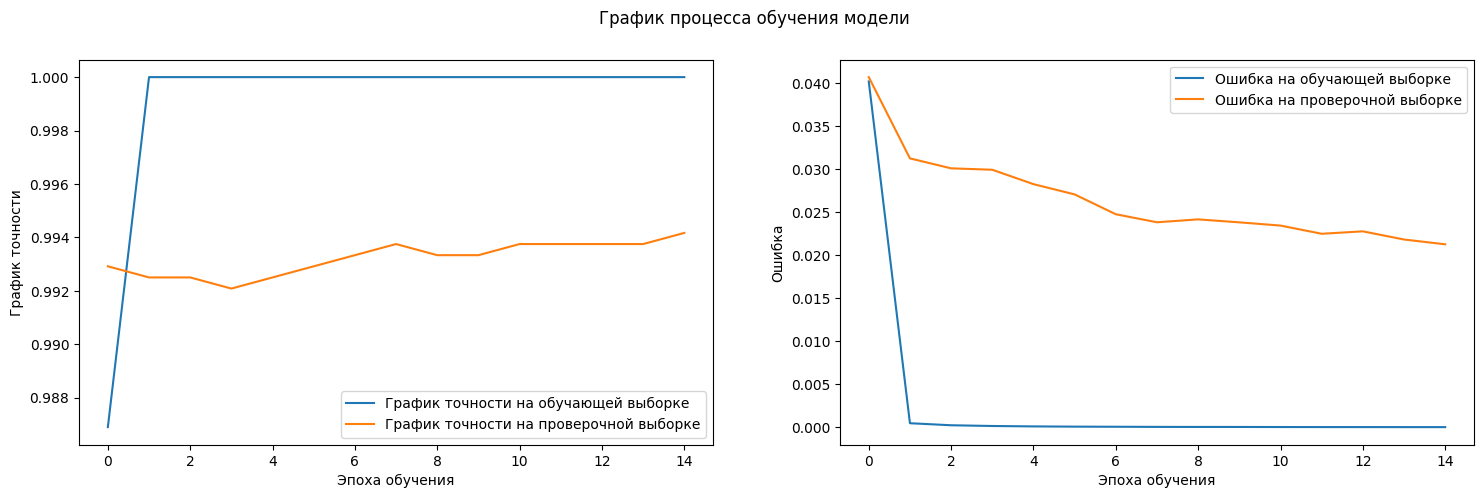

In [86]:
show_plot(history)

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


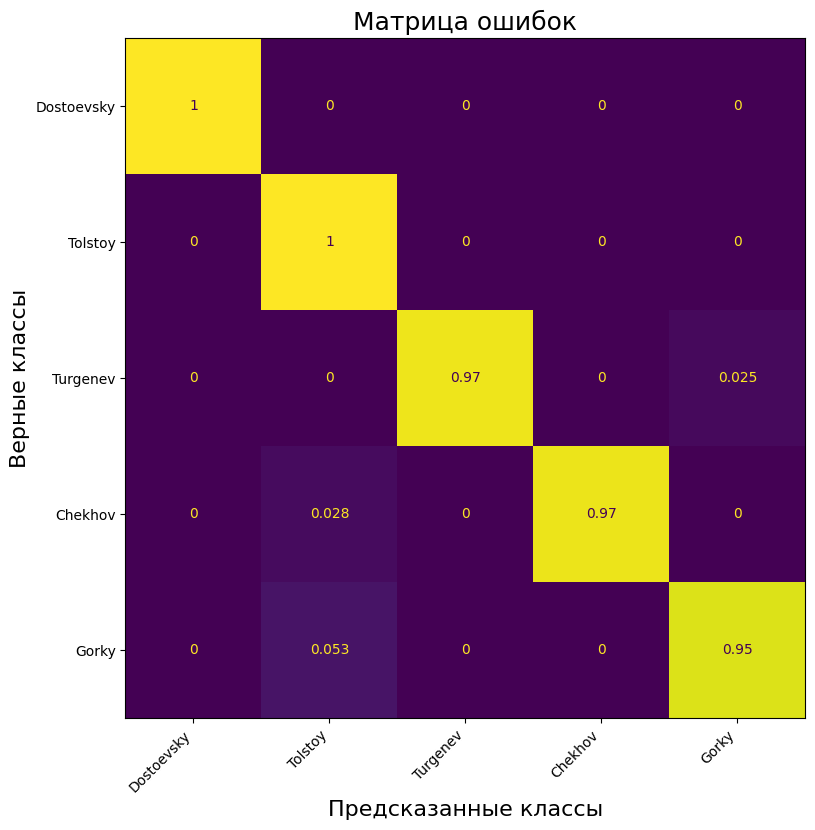


Средняя точность распознавания:  98%


In [87]:
y_pred = model_bow.predict(x_test_bow)

show_confusion_matrix(y_test, y_pred, CLASS_LIST_BALANCE)